In [8]:
import pyNN.spiNNaker as sim

2026-04-17 09:20:52 INFO: Read configs files: /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/spinn_utilities/spinn_utilities.cfg, /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/spinn_machine/spinn_machine.cfg, /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/pacman/pacman.cfg, /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/spinnman/spinnman.cfg, /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/spinn_front_end_common/interface/spinnaker.cfg, /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/spynnaker/pyNN/spynnaker.cfg, /Users/peterpalaciosjr/.spynnaker.cfg
2026-04-17 09:20:52 INFO: Read configs files: /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/spinn_utilities/spinn_utilities.cfg, /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/spinn_machine/spinn_machine.cfg, /opt/anaconda3/envs/spyNNakerdemo/lib/python3.14/site-packages/pacman/pacman.cfg, /opt/anaconda3/envs/spyN

store logs skipped as configs not loaded.


2026-04-17 09:20:53 INFO: Running for 1 steps for a total of 10000.0ms
2026-04-17 09:20:53 INFO: Run 1 of 1
2026-04-17 09:20:53 INFO: Sdram usage per chip report skipped as cfg Reports:write_sdram_usage_report_per_chip is False
2026-04-17 09:20:53 INFO: Drift report skipped as virtual_board
2026-04-17 09:20:53 INFO: Creating live event connection database in /Users/peterpalaciosjr/Santamaria's Lab/Projects/spyNNakerdemo/reports/2026-04-17-09-20-52-931170/run_1/input_output_database.sqlite3
Creating graph description database
|0%                          50%                         100%|
2026-04-17 09:20:53 INFO: Create database interface took 0:00:00.011971 
2026-04-17 09:20:53 INFO: ** Notifying external sources that the database is ready for reading **
2026-04-17 09:20:53 INFO: Create notification protocol took 0:00:00.000332 
2026-04-17 09:20:53 INFO: Runtime Update skipped as virtual_board
2026-04-17 09:20:53 INFO: Application runner skipped as virtual_board
2026-04-17 09:20:53 INF

{0: np.int64(0), 1: np.int64(0), 2: np.int64(0), 3: np.int64(0), 4: np.int64(0), 5: np.int64(0), 6: np.int64(0), 7: np.int64(0), 8: np.int64(0), 9: np.int64(0), 10: np.int64(0), 11: np.int64(0), 12: np.int64(0), 13: np.int64(0), 14: np.int64(0), 15: np.int64(0), 16: np.int64(0), 17: np.int64(0), 18: np.int64(0), 19: np.int64(0), 20: np.int64(0), 21: np.int64(0), 22: np.int64(0), 23: np.int64(0), 24: np.int64(0), 25: np.int64(0), 26: np.int64(0), 27: np.int64(0), 28: np.int64(0), 29: np.int64(0), 30: np.int64(0), 31: np.int64(0), 32: np.int64(0), 33: np.int64(0), 34: np.int64(0), 35: np.int64(0), 36: np.int64(0), 37: np.int64(0), 38: np.int64(0), 39: np.int64(0), 40: np.int64(0), 41: np.int64(0), 42: np.int64(0), 43: np.int64(0), 44: np.int64(0), 45: np.int64(0), 46: np.int64(0), 47: np.int64(0), 48: np.int64(0), 49: np.int64(0), 50: np.int64(0), 51: np.int64(0), 52: np.int64(0), 53: np.int64(0), 54: np.int64(0), 55: np.int64(0), 56: np.int64(0), 57: np.int64(0), 58: np.int64(0), 59: np

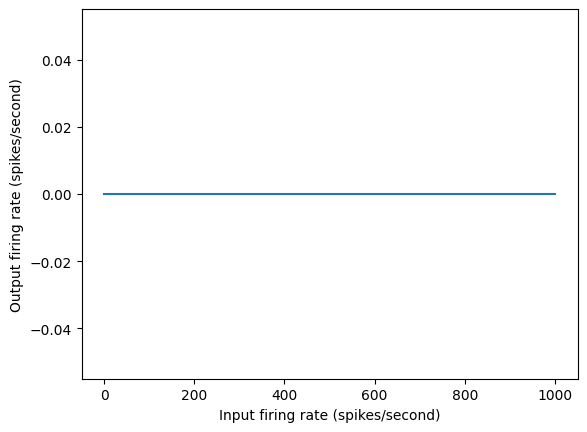

In [19]:
# Copyright (c) 2017-2019 The University of Manchester
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU General Public License for more details.
#
# You should have received a copy of the GNU General Public License
# along with this program.  If not, see <http://www.gnu.org/licenses/>.

"""
A population of integrate-and-firing neurons with different input firing rates
(example used in the HBP Neuromorphic Computing Guidebook)
"""

import numpy as np
import matplotlib.pyplot as plt

sim.setup(timestep=1.0, min_delay=1.0)

# create cells
cell_params = {
    'cm': 0.25, 'tau_m': 10.0, 'tau_refrac': 2.0,
    'tau_syn_E': 2.5, 'tau_syn_I': 2.5,
    'v_reset': -70.0, 'v_rest': -65.0, 'v_thresh': -55.0}

neurons = sim.Population(100, sim.IF_cond_exp(**cell_params))
inputs = sim.Population(100, sim.SpikeSourcePoisson(rate=0.0))

# set input firing rates as a linear function of cell index
input_firing_rates = np.linspace(0.0, 1000.0, num=inputs.size)
inputs.set(rate=input_firing_rates)

# create one-to-one connections
wiring = sim.OneToOneConnector()
static_synapse = sim.StaticSynapse(weight=0.1, delay=2.0)
connections = sim.Projection(inputs, neurons, wiring, static_synapse)

# configure recording
neurons.record('spikes')

# run simulation
sim_duration = 10.0  # seconds
sim.run(sim_duration*1000.0)

# retrieve recorded data
spike_counts = neurons.get_spike_counts()
print(spike_counts)
output_firing_rates = np.array(
    [value for (key, value) in sorted(spike_counts.items())])/sim_duration

sim.end()

# plot graph
plt.plot(input_firing_rates, output_firing_rates)
plt.xlabel("Input firing rate (spikes/second)")
plt.ylabel("Output firing rate (spikes/second)")
plt.savefig("simple_example.png")
plt.show();